In [1]:
# Import essential libraries for tips dataset regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
#import tips dataset
data = sns.load_dataset("tips")

In [3]:
data["sex"] = data["sex"].cat.codes
data["time"] = data["time"].cat.codes
data["smoker"] = data["smoker"].cat.codes
data = pd.get_dummies(data, prefix="day", columns=["day"])

In [4]:
X = data.drop('tip', axis=1)
y = data['tip']

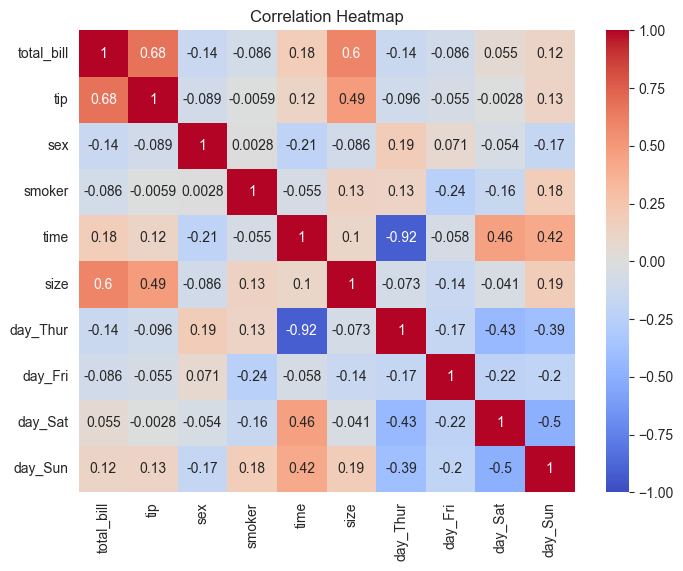

In [5]:
# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap')
plt.show()

In [6]:

data['tip_percentage'] = data['tip'] / data['total_bill'] * 100
data['per_person_total'] = data['total_bill'] / data['size']
data['is_weekend'] = data['day_Sat'] | data['day_Sun']
selected_features = ['total_bill', 'size', 'time', 'day_Sat', 'day_Sun', 'tip_percentage', 'per_person_total', 'is_weekend']
X_selected = data[selected_features]


In [7]:
X = X_selected.astype(np.float64)
y = data['tip'].astype(np.float64)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
# Initialize the model
lr_model = LinearRegression()
# Fit the model
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# Print the intercept and coefficients
print("Intercept:", lr_model.intercept_)
print("\nCoefficients:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"{feature}: {coef}")

Intercept: -2.320866886962074

Coefficients:
total_bill: 0.13002577242379026
size: 0.16508682357067406
time: -0.06930262929836821
day_Sat: 0.03667965407429484
day_Sun: -0.07302119768002387
tip_percentage: 0.14665460445694023
per_person_total: 0.008980631996781563
is_weekend: -0.036341543605729526


In [10]:
# Initialize Lasso model
lasso_model = Lasso(alpha=0.01)  # alpha is the regularization strength

# Fit the model
lasso_model.fit(X_train, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [11]:
# Print the intercept and coefficients
print("Lasso Intercept:", lasso_model.intercept_)
print("\nLasso Coefficients:")
for feature, coef in zip(X.columns, lasso_model.coef_):
    print(f"{feature}: {coef}")

Lasso Intercept: -2.162693574898962

Lasso Coefficients:
total_bill: 0.13732902192563845
size: 0.09619402638758116
time: -0.03473518005282518
day_Sat: 0.0
day_Sun: -0.0659550639082481
tip_percentage: 0.14569690878132913
per_person_total: -0.00980386733304947
is_weekend: -0.0


In [12]:

def print_evaluation_results(metrics, model_name=None):
    """
    Print formatted evaluation results.
    
    Parameters:
    -----------
    metrics : dict
        Dictionary containing train/test metrics
    model_name : str, optional
        Name of the model for display
    """
    # Display results
    if model_name:
        print(f"\n{'='*60}")
        print(f"  {model_name}")
        print(f"{'='*60}")
    
    print(f"\n{'Metric':<25} {'Training':<15} {'Test':<15} {'Difference':<15}")
    print("-" * 70)
    print(f"{'R² Score':<25} {metrics['train']['r2']:<15.4f} {metrics['test']['r2']:<15.4f} {metrics['overfit_gap']:<15.4f}")
    print(f"{'RMSE':<25} {metrics['train']['rmse']:<15.4f} {metrics['test']['rmse']:<15.4f} {metrics['test']['rmse'] - metrics['train']['rmse']:<15.4f}")
    print(f"{'MAE':<25} {metrics['train']['mae']:<15.4f} {metrics['test']['mae']:<15.4f} {metrics['test']['mae'] - metrics['train']['mae']:<15.4f}")
    print(f"{'MSE':<25} {metrics['train']['mse']:<15.4f} {metrics['test']['mse']:<15.4f} {metrics['test']['mse'] - metrics['train']['mse']:<15.4f}")
    
    # Interpretation
    print(f"\n{'Interpretation:'}")
    if metrics['overfit_gap'] > 0.1:
        print("  ⚠️  Significant overfitting detected (R² gap > 0.1)")
    elif metrics['overfit_gap'] > 0.05:
        print("  ⚡ Mild overfitting (R² gap between 0.05-0.1)")
    else:
        print("  ✓  Good generalization (R² gap < 0.05)")
    
    print(f"  Average prediction error: ${metrics['test']['mae']:.2f}")
    print(f"  Model explains {metrics['test']['r2']*100:.1f}% of variance in test data")


def evaluate_model(model, X_train, y_train, X_test, y_test, model_name=None):
    """
    Comprehensive model evaluation with multiple metrics.
    
    Parameters:
    -----------
    model : sklearn model
        Trained model to evaluate
    X_train, y_train : array-like
        Training data
    X_test, y_test : array-like
        Test data
    model_name : str, optional
        Name of the model for display
    
    Returns:
    --------
    dict : Dictionary containing all metrics
    """
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    metrics = {
        'train': {
            'mse': mean_squared_error(y_train, y_train_pred),
            'rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'mae': mean_absolute_error(y_train, y_train_pred),
            'r2': r2_score(y_train, y_train_pred)
        },
        'test': {
            'mse': mean_squared_error(y_test, y_test_pred),
            'rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'mae': mean_absolute_error(y_test, y_test_pred),
            'r2': r2_score(y_test, y_test_pred)
        }
    }
    
    # Calculate overfitting indicator
    metrics['overfit_gap'] = metrics['train']['r2'] - metrics['test']['r2']

    return metrics


def compare_models(models_dict, X_train, y_train, X_test, y_test):
    """
    Compare multiple models and display results in a DataFrame.
    
    Parameters:
    -----------
    models_dict : dict
        Dictionary with model names as keys and fitted models as values
    
    Returns:
    --------
    pd.DataFrame : Comparison table of all models
    """
    results = []
    
    for name, model in models_dict.items():
        metrics = evaluate_model(model, X_train, y_train, X_test, y_test, model_name=name)
        results.append({
            'Model': name,
            'Train R²': metrics['train']['r2'],
            'Test R²': metrics['test']['r2'],
            'R² Gap': metrics['overfit_gap'],
            'Test RMSE': metrics['test']['rmse'],
            'Test MAE': metrics['test']['mae']
        })
    
    df = pd.DataFrame(results)
    df = df.sort_values('Test R²', ascending=False).reset_index(drop=True)
    
    print("\n" + "="*80)
    print("MODEL COMPARISON SUMMARY")
    print("="*80)
    print(df.to_string(index=False))
    print("\nBest Model:", df.iloc[0]['Model'], f"(Test R² = {df.iloc[0]['Test R²']:.4f})")
    
    return df

In [13]:
# Single model evaluation
metrics = evaluate_model(lr_model, X_train, y_train, X_test, y_test, model_name="Linear Regression")

# Compare multiple models
models = {
    "Linear Regression": lr_model,
    "Lasso Regression": lasso_model
}
comparison_df = compare_models(models, X_train, y_train, X_test, y_test)


MODEL COMPARISON SUMMARY
            Model  Train R²  Test R²    R² Gap  Test RMSE  Test MAE
Linear Regression  0.826314 0.827909 -0.001595   0.463799  0.302538
 Lasso Regression  0.825715 0.826910 -0.001194   0.465143  0.293130

Best Model: Linear Regression (Test R² = 0.8279)



MODEL COMPARISON SUMMARY
          Model  Train R²   Test R²    R² Gap  Test RMSE  Test MAE
  Lasso (α=0.5)  0.812301  0.842596 -0.030294   0.443566  0.287899
  Lasso (α=0.1)  0.821538  0.833653 -0.012115   0.455992  0.276544
  Lasso (α=1.0)  0.792143  0.830643 -0.038501   0.460099  0.338216
Lasso (α=0.005)  0.826164  0.827654 -0.001490   0.464141  0.297376
 Lasso (α=0.01)  0.825715  0.826910 -0.001194   0.465143  0.293130
Lasso (α=0.001)  0.826301  0.826868 -0.000567   0.465199  0.301937
 Lasso (α=0.05)  0.822746  0.826189 -0.003443   0.466110  0.283219
  Lasso (α=5.0)  0.270160  0.309525 -0.039366   0.929018  0.815350
 Lasso (α=10.0)  0.000000 -0.158961  0.158961   1.203606  1.047104

Best Model: Lasso (α=0.5) (Test R² = 0.8426)


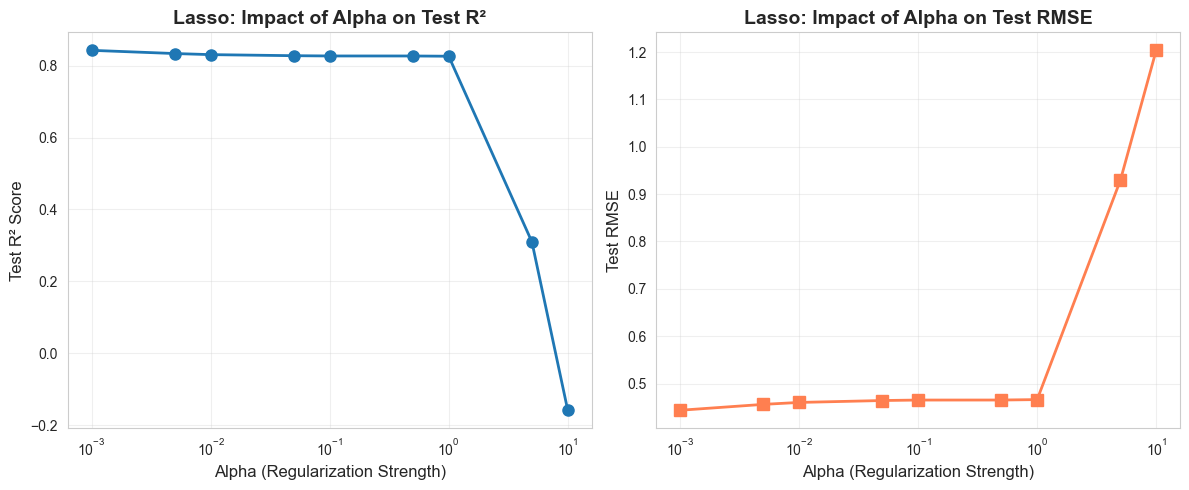

In [14]:
# Create Lasso models with different alpha values
alphas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
lasso_models = {}

# Train Lasso models with different alphas
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=100000)
    model.fit(X_train, y_train)
    lasso_models[f'Lasso (α={alpha})'] = model

# Compare all Lasso models
lasso_comparison = compare_models(lasso_models, X_train, y_train, X_test, y_test)

# Visualize the impact of alpha on model performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(alphas, lasso_comparison['Test R²'], marker='o', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('Test R² Score', fontsize=12)
plt.title('Lasso: Impact of Alpha on Test R²', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(alphas, lasso_comparison['Test RMSE'], marker='s', color='coral', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('Test RMSE', fontsize=12)
plt.title('Lasso: Impact of Alpha on Test RMSE', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Define the parameter grid
param_grid = {'alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]}

# Create a GridSearchCV object
grid_search = GridSearchCV(
    Lasso(max_iter=100000), 
    param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error',
    return_train_score=True
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best negative MSE:", grid_search.best_score_)
print("Best actual MSE:", -grid_search.best_score_)

# Use the best model for final evaluation
best_lasso_model = grid_search.best_estimator_

# Evaluate the best model
metrics = evaluate_model(best_lasso_model, X_train, y_train, X_test, y_test)
print_evaluation_results(metrics, "Best Lasso Model (via GridSearchCV)")

# Compare with original models
models = {
    "Linear Regression": lr_model,
    "Lasso (manual α=0.01)": lasso_model,
    "Lasso (GridSearchCV)": best_lasso_model
}
comparison_df = compare_models(models, X_train, y_train, X_test, y_test)

Best parameters: {'alpha': 0.5}
Best negative MSE: -0.5053984961195676
Best actual MSE: 0.5053984961195676

  Best Lasso Model (via GridSearchCV)

Metric                    Training        Test            Difference     
----------------------------------------------------------------------
R² Score                  0.8123          0.8426          -0.0303        
RMSE                      0.6175          0.4436          -0.1740        
MAE                       0.3625          0.2879          -0.0746        
MSE                       0.3813          0.1968          -0.1846        

Interpretation:
  ✓  Good generalization (R² gap < 0.05)
  Average prediction error: $0.29
  Model explains 84.3% of variance in test data

MODEL COMPARISON SUMMARY
                Model  Train R²  Test R²    R² Gap  Test RMSE  Test MAE
 Lasso (GridSearchCV)  0.812301 0.842596 -0.030294   0.443566  0.287899
    Linear Regression  0.826314 0.827909 -0.001595   0.463799  0.302538
Lasso (manual α=0.01)  0.82571

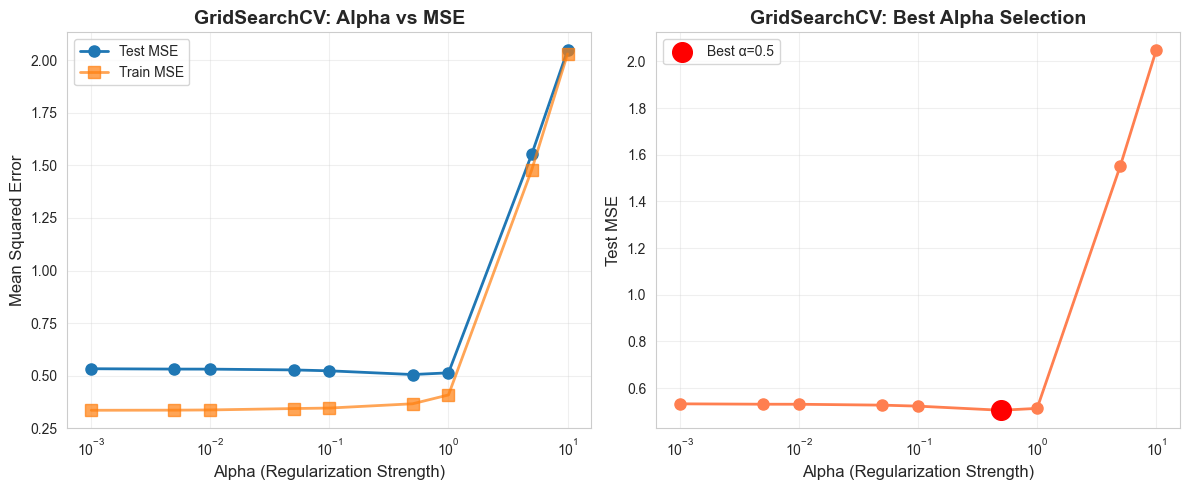


Feature Coefficients (Best Lasso Model)
total_bill          :   0.1303
size                :   0.0000 (eliminated)
time                :  -0.0000 (eliminated)
day_Sat             :  -0.0000 (eliminated)
day_Sun             :  -0.0000 (eliminated)
tip_percentage      :   0.1304
per_person_total    :  -0.0000 (eliminated)
is_weekend          :  -0.0000 (eliminated)


In [16]:

# Visualize GridSearchCV results
results_df = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results_df['param_alpha'], -results_df['mean_test_score'], marker='o', linewidth=2, markersize=8, label='Test MSE')
plt.plot(results_df['param_alpha'], -results_df['mean_train_score'], marker='s', linewidth=2, markersize=8, label='Train MSE', alpha=0.7)
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('GridSearchCV: Alpha vs MSE', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
alphas_list = results_df['param_alpha'].values
test_scores = -results_df['mean_test_score'].values
best_idx = np.argmin(test_scores)
plt.plot(alphas_list, test_scores, marker='o', linewidth=2, markersize=8, color='coral')
plt.scatter(alphas_list[best_idx], test_scores[best_idx], color='red', s=200, zorder=5, label=f'Best α={alphas_list[best_idx]}')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('Test MSE', fontsize=12)
plt.title('GridSearchCV: Best Alpha Selection', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print feature coefficients of best model
print("\n" + "="*60)
print("Feature Coefficients (Best Lasso Model)")
print("="*60)
for feature, coef in zip(X.columns, best_lasso_model.coef_):
    if coef != 0:
        print(f"{feature:20s}: {coef:8.4f}")
    else:
        print(f"{feature:20s}: {coef:8.4f} (eliminated)")